In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
import numpy as np

In [7]:
df=pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [8]:
df.shape

(27, 2)

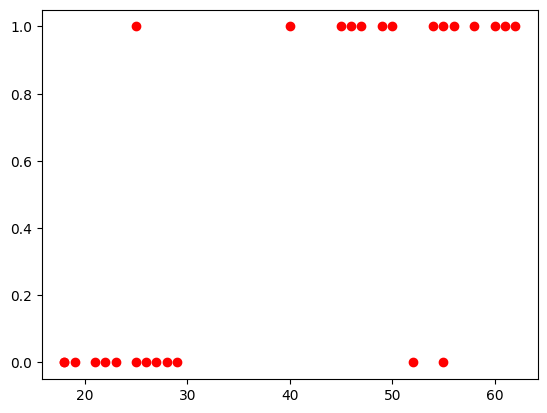

In [9]:
plt.scatter(df.age,df.bought_insurance,color="red")

In [10]:
x=df[['age']]
y=df[['bought_insurance']]

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=10)

In [12]:
x_test

,age
8,62
13,29
9,61
21,26
0,22
11,28


In [13]:
x_train

,age
16,25
17,58
12,27
24,50
1,25
4,46
5,56
2,47
15,55
22,40


In [16]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
model.coef_

array([[0.11307708]])

In [18]:
model.intercept_

array([-4.15311919])

In [20]:
y_predicted=model.predict(x_test)

In [21]:
y_predicted

array([1, 0, 1, 0, 0, 0])

In [24]:
df['proba']=model.predict_proba(df[['age']])[:,1]
df

,age,bought_insurance,proba
0,22,0,0.159035
1,25,0,0.209790
2,47,1,0.761606
3,52,0,0.849014
4,46,1,0.740473
5,56,1,0.898366
6,55,0,0.887566
7,60,1,0.932862
8,62,1,0.945713
9,61,1,0.939607


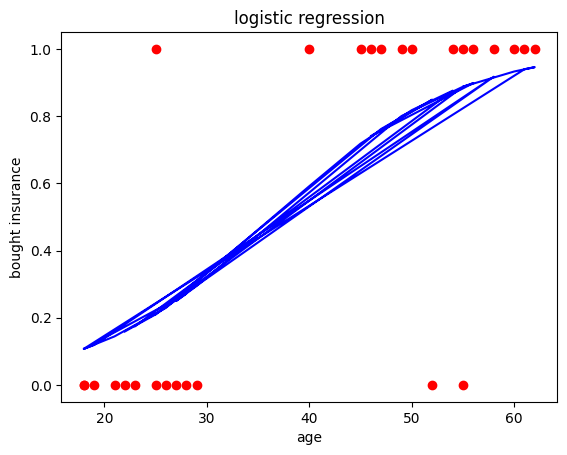

In [40]:
plt.scatter(df.age,df.bought_insurance,color="red")
plt.plot(df['age'],df['proba'],color='blue')
plt.xlabel("age")
plt.ylabel("bought insurance")
plt.title("logistic regression")
plt.show()

In [31]:
import math
def sigmoid(x):
    return 1/(1+math.exp(-x))

In [29]:
def prediction_function(age):
    z=0.112*age +(-4.20)
    y=sigmoid(z)
    return y

In [33]:
age=37.5
prediction_function(age)

0.5

In [34]:
age=40
prediction_function(age)

0.569546223939229

In [35]:
age=82
prediction_function(age)

0.9931999362344026

In [36]:
age=77
prediction_function(age)

0.9881557756401541

In [39]:
age=13
prediction_function(age)

0.0604264033944818

In [38]:
age=1
prediction_function(age)

0.016496061288316648

In [41]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(x)
accuracy=accuracy_score(y,y_pred)
print("accuracy:",accuracy)

accuracy: 0.8888888888888888
